<a href="https://colab.research.google.com/github/aaryapatkarworks/ML/blob/main/ML_Lab_01_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Assignment - Pima Diabetes Dataset Analysis

This notebook contains comprehensive analysis of the Pima Indian Diabetes dataset including:
- Data preprocessing and cleaning
- Exploratory Data Analysis
- Feature engineering and selection
- Data visualization
- Feature importance analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('diabetes.csv')

In [4]:
print("Original Dataset:\n")
print(df)

Original Dataset:

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  


In [5]:
print("First 5 rows and last 5 rows of the original dataset")
print(df.head())
print(df.tail())

First 5 rows and last 5 rows of the original dataset
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121   

In [6]:
print("Rows 4 to 12\n")
print(df.iloc[4:13])

Rows 4 to 12

    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
4             0      137             40             35      168  43.1   
5             5      116             74              0        0  25.6   
6             3       78             50             32       88  31.0   
7            10      115              0              0        0  35.3   
8             2      197             70             45      543  30.5   
9             8      125             96              0        0   0.0   
10            4      110             92              0        0  37.6   
11           10      168             74              0        0  38.0   
12           10      139             80              0        0  27.1   

    DiabetesPedigreeFunction  Age  Outcome  
4                      2.288   33        1  
5                      0.201   30        0  
6                      0.248   26        1  
7                      0.134   29        0  
8                      0.158  

In [7]:
print("First 19 rows of original dataset\n")
print(df.iloc[0:20])

First 19 rows of original dataset

    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0             6      148             72             35        0  33.6   
1             1       85             66             29        0  26.6   
2             8      183             64              0        0  23.3   
3             1       89             66             23       94  28.1   
4             0      137             40             35      168  43.1   
5             5      116             74              0        0  25.6   
6             3       78             50             32       88  31.0   
7            10      115              0              0        0  35.3   
8             2      197             70             45      543  30.5   
9             8      125             96              0        0   0.0   
10            4      110             92              0        0  37.6   
11           10      168             74              0        0  38.0   
12           10 

In [8]:
print("Shape of the original dataset\n")
print(df.shape)

Shape of the original dataset

(768, 9)


In [9]:
print("Feature description\n")
print(df.info())

Feature description

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


In [10]:
print("Statistical Description\n")
print(df.describe())

Statistical Description

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0

In [11]:
print("Number of duplicates in the dataset\n")
print(df.duplicated().sum())

Number of duplicates in the dataset

0


In [12]:
print("Removing duplicates\n")
df = df.drop_duplicates()
print(df.duplicated().sum())
print(df)

Removing duplicates

0
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        

In [13]:
# Identify missing values
print("Identifying missing values\n")
print(df.isnull().sum())

Identifying missing values

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [14]:
print("BMI column with missing values\n")
print(df['BMI'])

BMI column with missing values

0      33.6
1      26.6
2      23.3
3      28.1
4      43.1
       ... 
763    32.9
764    36.8
765    26.2
766    30.1
767    30.4
Name: BMI, Length: 768, dtype: float64


In [15]:
print("Replacing missing values with 0 imputation\n")
df_filled_zero = df.fillna(0)
print("Missing values after 0 imputation\n", df_filled_zero.isnull().sum())
print(df_filled_zero)

Replacing missing values with 0 imputation

Missing values after 0 imputation
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70      

In [16]:
print("Identifying appropriate values with central tendency\n")

print("Mean of Glucose:", df['Glucose'].mean())
print("Median of BloodPressure:", df['BloodPressure'].median())
print("Mode of Outcome:", df['Outcome'].mode()[0])

Identifying appropriate values with central tendency

Mean of Glucose: 120.89453125
Median of BloodPressure: 72.0
Mode of Outcome: 0


In [17]:
# Impute missing values with median
numeric_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
imputer = SimpleImputer(strategy='median')
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])
print(df)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6.0    148.0           72.0           35.0      0.0  33.6   
1            1.0     85.0           66.0           29.0      0.0  26.6   
2            8.0    183.0           64.0            0.0      0.0  23.3   
3            1.0     89.0           66.0           23.0     94.0  28.1   
4            0.0    137.0           40.0           35.0    168.0  43.1   
..           ...      ...            ...            ...      ...   ...   
763         10.0    101.0           76.0           48.0    180.0  32.9   
764          2.0    122.0           70.0           27.0      0.0  36.8   
765          5.0    121.0           72.0           23.0    112.0  26.2   
766          1.0    126.0           60.0            0.0      0.0  30.1   
767          1.0     93.0           70.0           31.0      0.0  30.4   

     DiabetesPedigreeFunction   Age  Outcome  
0                       0.627  50.0        1  
1                

In [18]:
print("\nAfter imputation - missing values count:")
print(df.isnull().sum())


After imputation - missing values count:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [19]:
print("Splitting data into Independent and Dependent features\n")
X = df.drop(['Outcome'], axis=1)
y = df['Outcome']
print("\nIndependent variables (X):")
print(X.head())
print("\nDependent variable (y):")
print(y.head())
print("\n")

Splitting data into Independent and Dependent features


Independent variables (X):
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          6.0    148.0           72.0           35.0      0.0  33.6   
1          1.0     85.0           66.0           29.0      0.0  26.6   
2          8.0    183.0           64.0            0.0      0.0  23.3   
3          1.0     89.0           66.0           23.0     94.0  28.1   
4          0.0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction   Age  
0                     0.627  50.0  
1                     0.351  31.0  
2                     0.672  32.0  
3                     0.167  21.0  
4                     2.288  33.0  

Dependent variable (y):
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64




In [20]:
print("Data Encoding Steps\n")
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print("Outcome after label encoding:", y_encoded[:30])
print("\n")

Data Encoding Steps

Outcome after label encoding: [1 0 1 0 1 0 1 0 1 1 0 1 0 1 1 1 1 1 0 1 0 0 1 1 1 1 1 0 0 0]




In [21]:
print("Data Transformation - Normalization[Min Max]\n")
scaler = MinMaxScaler()
X_normalized = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("Normalized data (first 5 rows):")
print(X_normalized.head())
print("\n")

Data Transformation - Normalization[Min Max]

Normalized data (first 5 rows):
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.352941  0.743719       0.590164       0.353535  0.000000  0.500745   
1     0.058824  0.427136       0.540984       0.292929  0.000000  0.396423   
2     0.470588  0.919598       0.524590       0.000000  0.000000  0.347243   
3     0.058824  0.447236       0.540984       0.232323  0.111111  0.418778   
4     0.000000  0.688442       0.327869       0.353535  0.198582  0.642325   

   DiabetesPedigreeFunction       Age  
0                  0.234415  0.483333  
1                  0.116567  0.166667  
2                  0.253629  0.183333  
3                  0.038002  0.000000  
4                  0.943638  0.200000  




In [22]:
print("Data Transformation - Normalization[Z-score]\n")
scaler_std = StandardScaler()
X_standardized = pd.DataFrame(scaler_std.fit_transform(X), columns=X.columns)

print("Standardized data (first 5 rows):")
print(X_standardized.head())
print("\n")

Data Transformation - Normalization[Z-score]

Standardized data (first 5 rows):
   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.848324       0.149641       0.907270 -0.692891  0.204013   
1    -0.844885 -1.123396      -0.160546       0.530902 -0.692891 -0.684422   
2     1.233880  1.943724      -0.263941      -1.288212 -0.692891 -1.103255   
3    -0.844885 -0.998208      -0.160546       0.154533  0.123302 -0.494043   
4    -1.141852  0.504055      -1.504687       0.907270  0.765836  1.409746   

   DiabetesPedigreeFunction       Age  
0                  0.468492  1.425995  
1                 -0.365061 -0.190672  
2                  0.604397 -0.105584  
3                 -0.920763 -1.041549  
4                  5.484909 -0.020496  




Exploratory Data Analysis - Visualizations:
Bar graph

Histogram


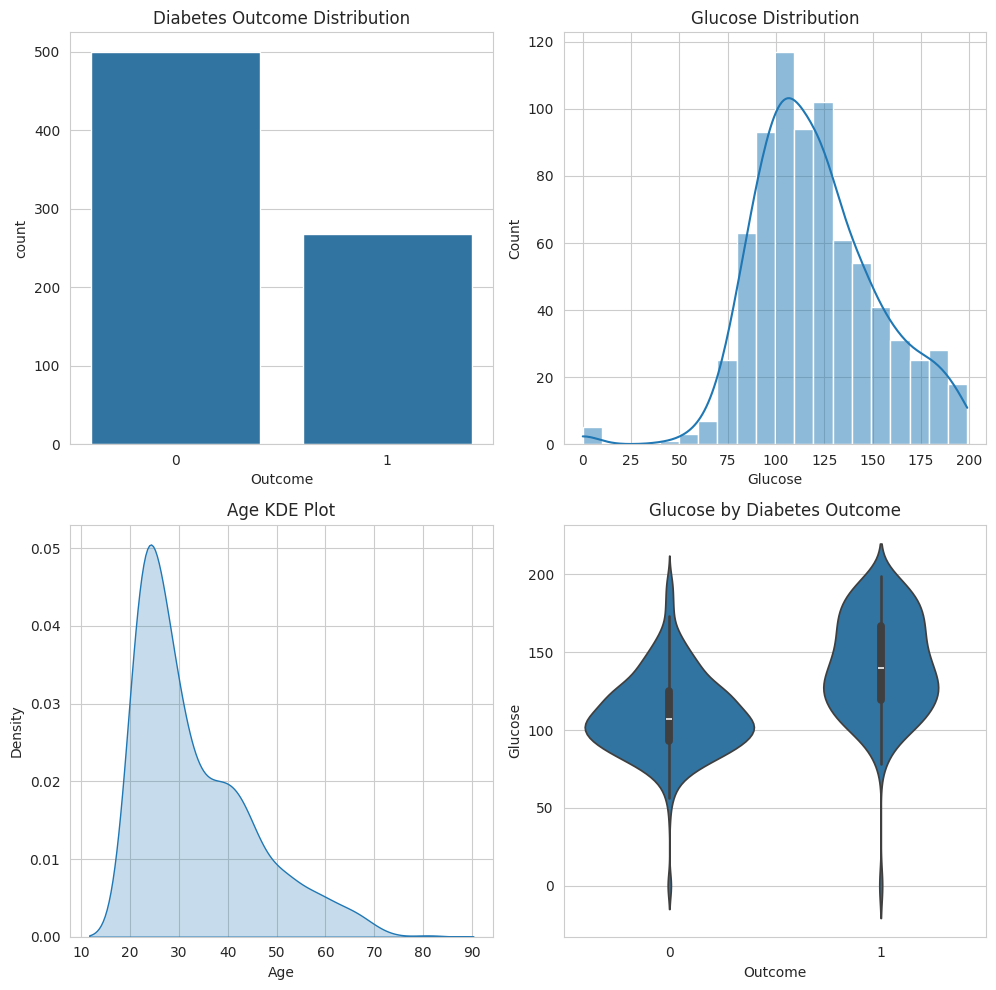

In [23]:
print("Exploratory Data Analysis - Visualizations:")
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))
print("Bar graph\n")
plt.subplot(2, 3, 1)
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Outcome Distribution")

plt.subplot(2, 3, 2)
sns.histplot(df['Glucose'], bins=20, kde=True)
plt.title("Glucose Distribution")
print("Histogram")

plt.subplot(2, 3, 4)
sns.kdeplot(df['Age'], fill=True)
plt.title("Age KDE Plot")

plt.subplot(2, 3, 5)
sns.violinplot(x='Outcome', y='Glucose', data=df)
plt.title("Glucose by Diabetes Outcome")

plt.tight_layout()
plt.show()

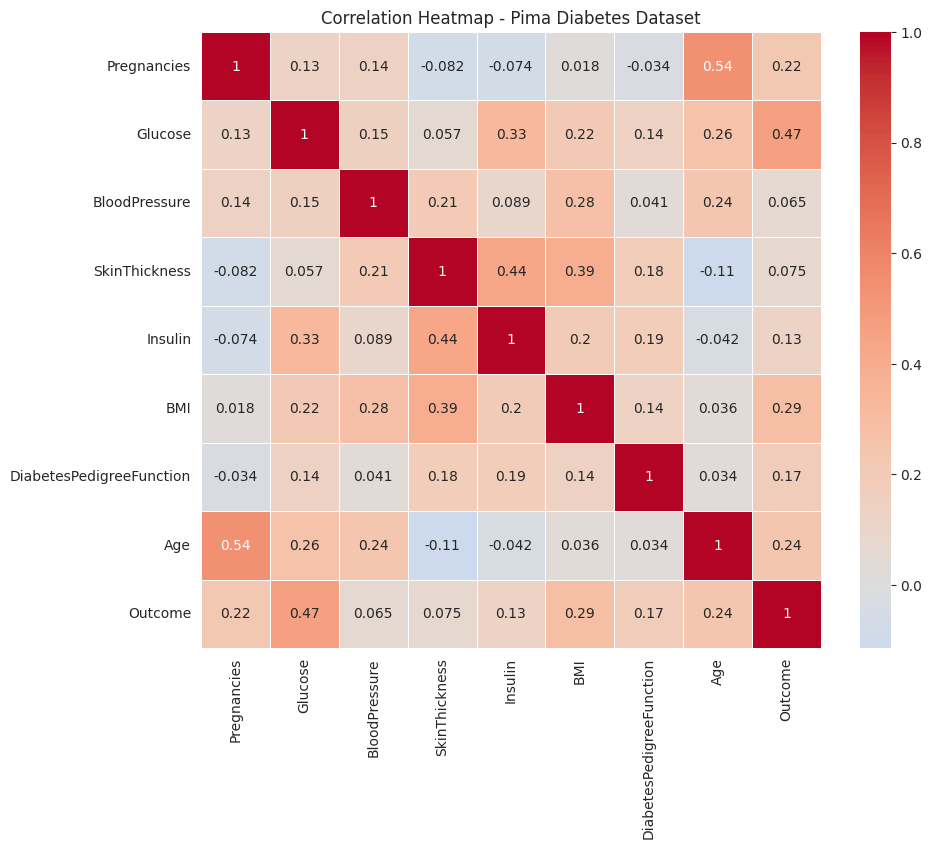

In [24]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Correlation Heatmap - Pima Diabetes Dataset")
plt.show()


Feature Importance Analysis:
Feature Importance Scores:
                    Feature       Score
1                   Glucose  213.161752
5                       BMI   71.772072
7                       Age   46.140611
0               Pregnancies   39.670227
6  DiabetesPedigreeFunction   23.871300
4                   Insulin   13.281108
3             SkinThickness    4.304381
2             BloodPressure    3.256950


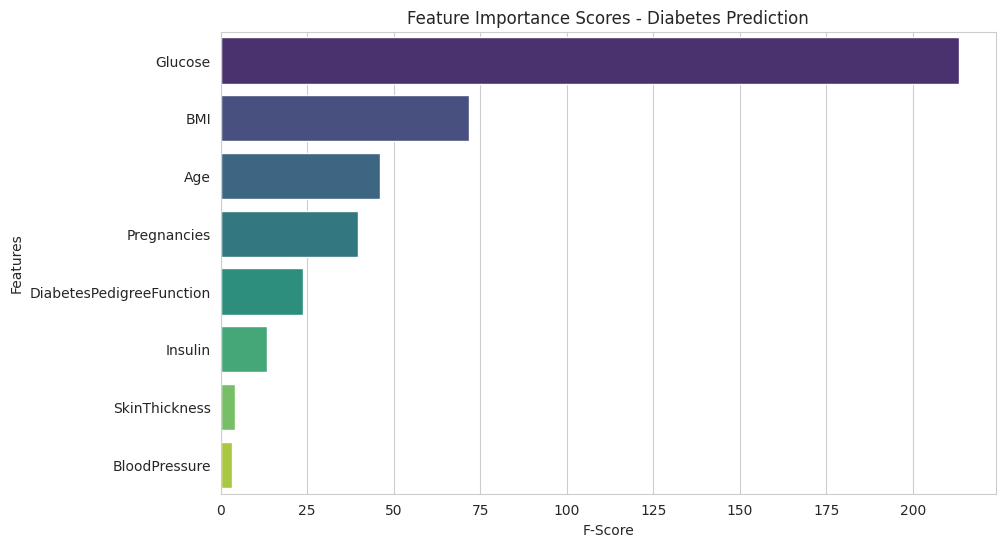

In [25]:
print("\nFeature Importance Analysis:")

# Convert target to numeric if needed
y_numeric = label_encoder.fit_transform(y)

# Feature selection using SelectKBest
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_normalized, y_numeric)

# Create feature importance dataframe
feature_scores = pd.DataFrame({
    'Feature': X_normalized.columns,
    'Score': selector.scores_
}).sort_values('Score', ascending=False)

print("Feature Importance Scores:")
print(feature_scores)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Score', y='Feature', data=feature_scores, palette='viridis')
plt.title("Feature Importance Scores - Diabetes Prediction")
plt.xlabel("F-Score")
plt.ylabel("Features")
plt.show()

In [26]:
# Summary Statistics by Outcome
print("\nSummary Statistics by Diabetes Outcome:")
print("\nNon-Diabetic (Outcome = 0):")
print(df[df['Outcome'] == 0].describe())

print("\nDiabetic (Outcome = 1):")
print(df[df['Outcome'] == 1].describe())


Summary Statistics by Diabetes Outcome:

Non-Diabetic (Outcome = 0):
       Pregnancies   Glucose  BloodPressure  SkinThickness     Insulin  \
count   500.000000  500.0000     500.000000     500.000000  500.000000   
mean      3.298000  109.9800      68.184000      19.664000   68.792000   
std       3.017185   26.1412      18.063075      14.889947   98.865289   
min       0.000000    0.0000       0.000000       0.000000    0.000000   
25%       1.000000   93.0000      62.000000       0.000000    0.000000   
50%       2.000000  107.0000      70.000000      21.000000   39.000000   
75%       5.000000  125.0000      78.000000      31.000000  105.000000   
max      13.000000  197.0000     122.000000      60.000000  744.000000   

              BMI  DiabetesPedigreeFunction         Age  Outcome  
count  500.000000                500.000000  500.000000    500.0  
mean    30.304200                  0.429734   31.190000      0.0  
std      7.689855                  0.299085   11.667655      0

In [27]:
# Data Quality Assessment
print("\nData Quality Assessment:")
print(f"Dataset Shape: {df.shape}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")
print(f"Data Types:")
print(df.dtypes)

print("\nTarget Variable Distribution:")
outcome_counts = df['Outcome'].value_counts()
print(outcome_counts)
print(f"Class Balance Ratio: {outcome_counts[0]/outcome_counts[1]:.2f}:1")


Data Quality Assessment:
Dataset Shape: (768, 9)
Missing Values: 0
Duplicate Rows: 0
Data Types:
Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Outcome                       int64
dtype: object

Target Variable Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64
Class Balance Ratio: 1.87:1
